In [1]:
import requests
from bs4 import BeautifulSoup as bs

# [네이트 판 댓글 예제](https://celltong.tistory.com/entry/%ED%8C%8C%EC%9D%B4%EC%8D%AC-%ED%81%AC%EB%A1%A4%EB%A7%81-%EA%B0%84%EB%8B%A8%ED%95%9C-%EC%8B%A4%EC%8A%B5-%EB%84%A4%EC%9D%B4%ED%8A%B8-%ED%8C%90-%EB%8C%93%EA%B8%80-%EC%88%98%EC%A7%91)

## html 문서 조회

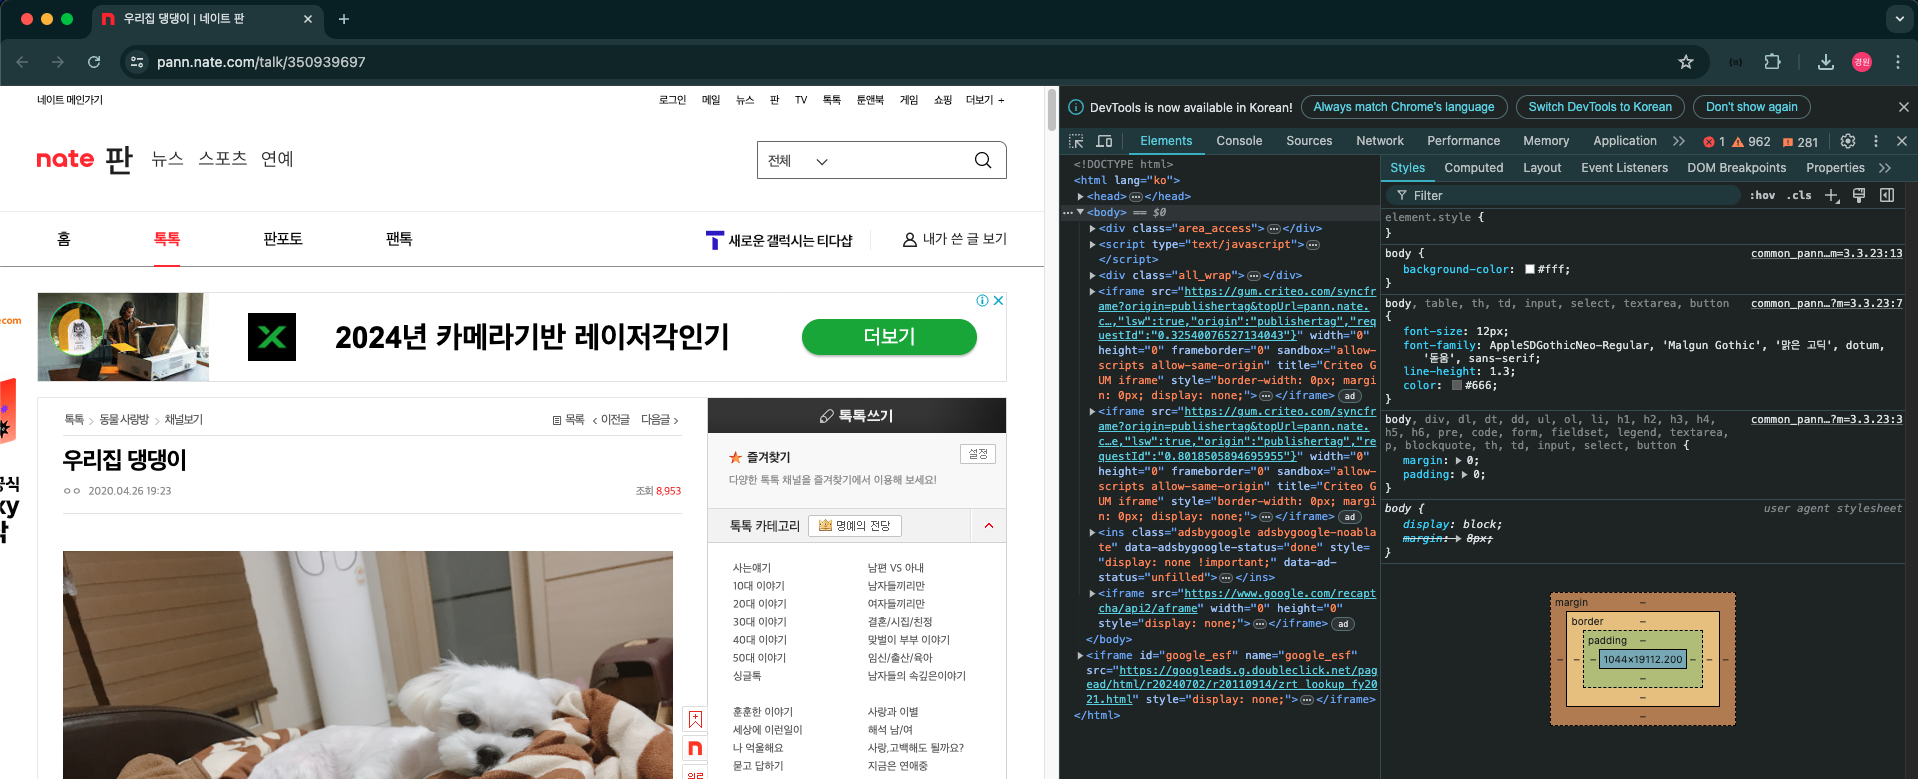

In [2]:
custom_header = {
    "user-agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36",
    "referer": "https://pann.ante.com/"
}
url = "https://pann.nate.com/talk/350939697"
response = requests.get(url, headers=custom_header)
response.raise_for_status()
response.status_code

200

In [3]:
response.text

'<!DOCTYPE HTML>\n<html lang="ko">\n    <head>\n<meta charset="utf-8" />\n<meta name="viewport" content="width=device-width, initial-scale=1" />\n<meta http-equiv="X-UA-Compatible" content="IE=edge" />\n<title>우리집 댕댕이 | 네이트 판</title>\n<link href="/favicon.ico?m=3.4.8"  type="image/x-icon" rel="shortcut icon" /> \n<link href="/pann_css/content_css.css?m=3.4.8"  rel="stylesheet" type="text/css" media="all" charset="utf-8" /><link href="/css/common_pann_v4.css?m=3.4.8"  rel="stylesheet" type="text/css" media="all" charset="utf-8" /><link href="/css/aticle_v3.css?m=3.4.8"  rel="stylesheet" type="text/css" media="all" charset="utf-8" /><link href="/css/editor.css?m=3.4.8"  rel="stylesheet" type="text/css" media="all" charset="utf-8" />\n<link href="/images/nate_pann.png?m=3.4.8"  rel="apple-touch-icon-precomposed" /><link href="/images/nate_pann.png?m=3.4.8"  rel="apple-touch-icon" />\n<script src="/js/common.js?m=2.2.52" type="text/javascript" ></script>\n<script src="/js/jquery-3.7.1.min.

In [4]:
soup = bs(response.text, "html.parser")
soup

<!DOCTYPE HTML>

<html lang="ko">
<head>
<meta charset="utf-8"/>
<meta content="width=device-width, initial-scale=1" name="viewport"/>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<title>우리집 댕댕이 | 네이트 판</title>
<link href="/favicon.ico?m=3.4.8" rel="shortcut icon" type="image/x-icon"/>
<link charset="utf-8" href="/pann_css/content_css.css?m=3.4.8" media="all" rel="stylesheet" type="text/css"/><link charset="utf-8" href="/css/common_pann_v4.css?m=3.4.8" media="all" rel="stylesheet" type="text/css"/><link charset="utf-8" href="/css/aticle_v3.css?m=3.4.8" media="all" rel="stylesheet" type="text/css"/><link charset="utf-8" href="/css/editor.css?m=3.4.8" media="all" rel="stylesheet" type="text/css"/>
<link href="/images/nate_pann.png?m=3.4.8" rel="apple-touch-icon-precomposed"/><link href="/images/nate_pann.png?m=3.4.8" rel="apple-touch-icon"/>
<script src="/js/common.js?m=2.2.52" type="text/javascript"></script>
<script src="/js/jquery-3.7.1.min.js?m=2.2.52" type="text/javascript

## 댓글 추출

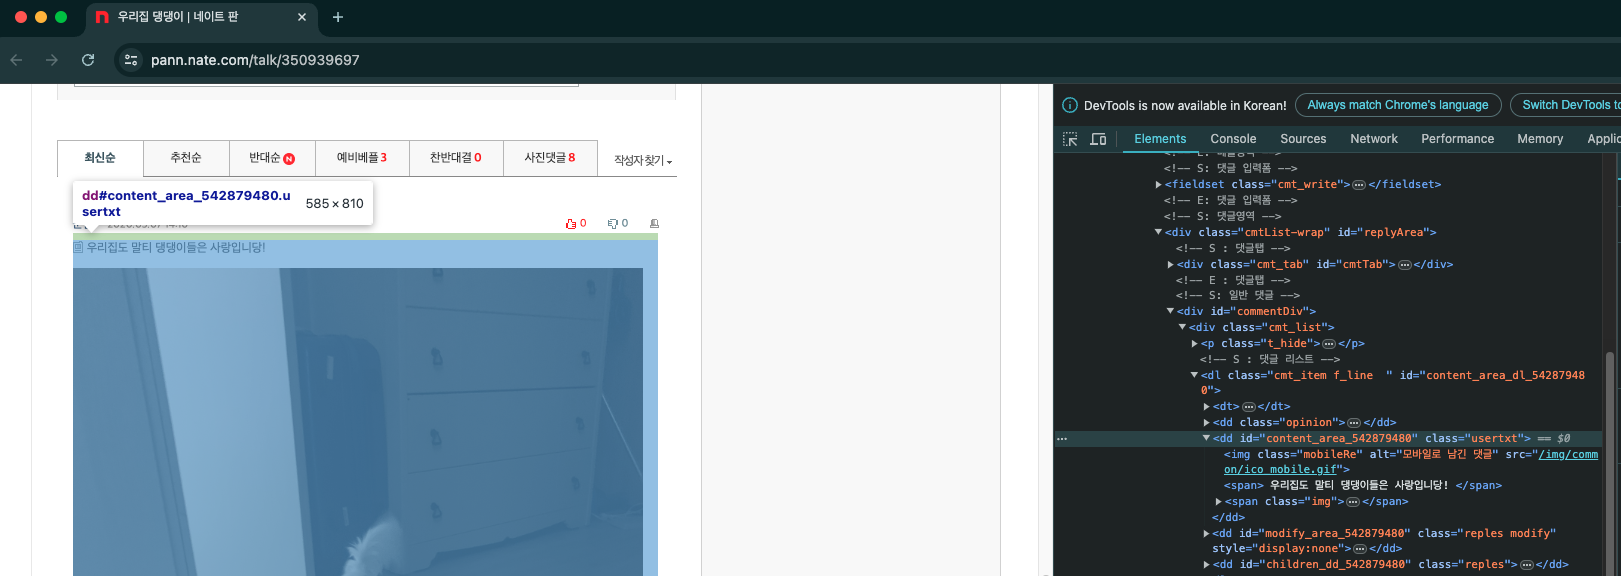

In [5]:
dd_list = soup.find_all("dd", class_="usertxt")
print(len(dd_list))

20


In [6]:
dd_list[0].get_text()

'\n 우리 댕댕이ㅋ\n\n\n '

In [7]:
dd_list[0].get_text().replace("\n","").replace("\t","") # 텝과 줄바꿈 제거

' 우리 댕댕이ㅋ '

## 함수

In [8]:
def main():
    custom_header = {
        "user-agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36",
        "referer": "https://pann.ante.com/"
    }
    url = "https://pann.nate.com/talk/350939697"
    response = requests.get(url, headers=custom_header)
    response.raise_for_status()
    soup = bs(response.text, "html.parser")

    return soup

In [9]:
soup = main()
soup

<!DOCTYPE HTML>

<html lang="ko">
<head>
<meta charset="utf-8"/>
<meta content="width=device-width, initial-scale=1" name="viewport"/>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<title>우리집 댕댕이 | 네이트 판</title>
<link href="/favicon.ico?m=3.4.8" rel="shortcut icon" type="image/x-icon"/>
<link charset="utf-8" href="/pann_css/content_css.css?m=3.4.8" media="all" rel="stylesheet" type="text/css"/><link charset="utf-8" href="/css/common_pann_v4.css?m=3.4.8" media="all" rel="stylesheet" type="text/css"/><link charset="utf-8" href="/css/aticle_v3.css?m=3.4.8" media="all" rel="stylesheet" type="text/css"/><link charset="utf-8" href="/css/editor.css?m=3.4.8" media="all" rel="stylesheet" type="text/css"/>
<link href="/images/nate_pann.png?m=3.4.8" rel="apple-touch-icon-precomposed"/><link href="/images/nate_pann.png?m=3.4.8" rel="apple-touch-icon"/>
<script src="/js/common.js?m=2.2.52" type="text/javascript"></script>
<script src="/js/jquery-3.7.1.min.js?m=2.2.52" type="text/javascript

In [10]:
def crawling(soup):
    dd_list = soup.find_all("dd", class_="usertxt")

    for idx, dd in enumerate(dd_list):
        comment = dd.get_text().replace("\n","").replace("\t","")
        print(f'{idx}번째 댓글\n>> {comment}')

In [11]:
crawling(soup)

0번째 댓글
>>  우리 댕댕이ㅋ 
1번째 댓글
>> 우리집도 말티 댕댕이들은 사랑입니당! 
2번째 댓글
>> ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ 다이쁨 완전 얼짱이넹
3번째 댓글
>> 우리 딸랑이 
4번째 댓글
>> 말티는 사랑입니당^^ 
5번째 댓글
>> 너무 귀엽당^^
6번째 댓글
>> 밑에서 두번째 사진 털때문인지 뾰루퉁한거 넘 귀여워요 ㅋㅋㅋㅋㅋ!울집강아지도 털때문에 가끔 눈이 화난눈 되거든요 ㅎㅎㅎㅎ 귀엽 ㅠ.ㅠ*
7번째 댓글
>> 우리집도 
8번째 댓글
>> 달릴 때 졸귘ㅋㅋ 눈이랑 코랑 동글동글 너무 귀엽 ㅠㅠㅠㅠㅠ
9번째 댓글
>> 안녕 칭구 
10번째 댓글
>> 개똥냄새 쩔게 생겼네
11번째 댓글
>> 안녕 난 두부야 
12번째 댓글
>> 아 너모 이쁘다. 항상 건강하자 아가
13번째 댓글
>> 힐링하고 갑니다❤️
14번째 댓글
>> 안뇽 ? 
15번째 댓글
>> 네츄럴 부스스.. 예쁘네요..^^
16번째 댓글
>> 으악 싑알 넘귀여워 말티즈 사랑해말티즈최고 말티즈 너무귀엽다
17번째 댓글
>> 순백의 청순함에서 깨발랄 ㅋ귀엽네요
18번째 댓글
>> 우리 댕댕이ㅋ 
19번째 댓글
>> 어머나!


# [벅스뮤직 음원차트 예제](https://celltong.tistory.com/entry/%ED%8C%8C%EC%9D%B4%EC%8D%AC-%ED%81%AC%EB%A1%A4%EB%A7%81-%EA%B0%84%EB%8B%A8%ED%95%9C-%EC%8B%A4%EC%8A%B5-%EB%B2%85%EC%8A%A4%EB%AE%A4%EC%A7%81-%EC%9D%8C%EC%9B%90%EC%B0%A8%ED%8A%B8-%EC%B6%94%EC%B6%9C)

## html 문서 조회

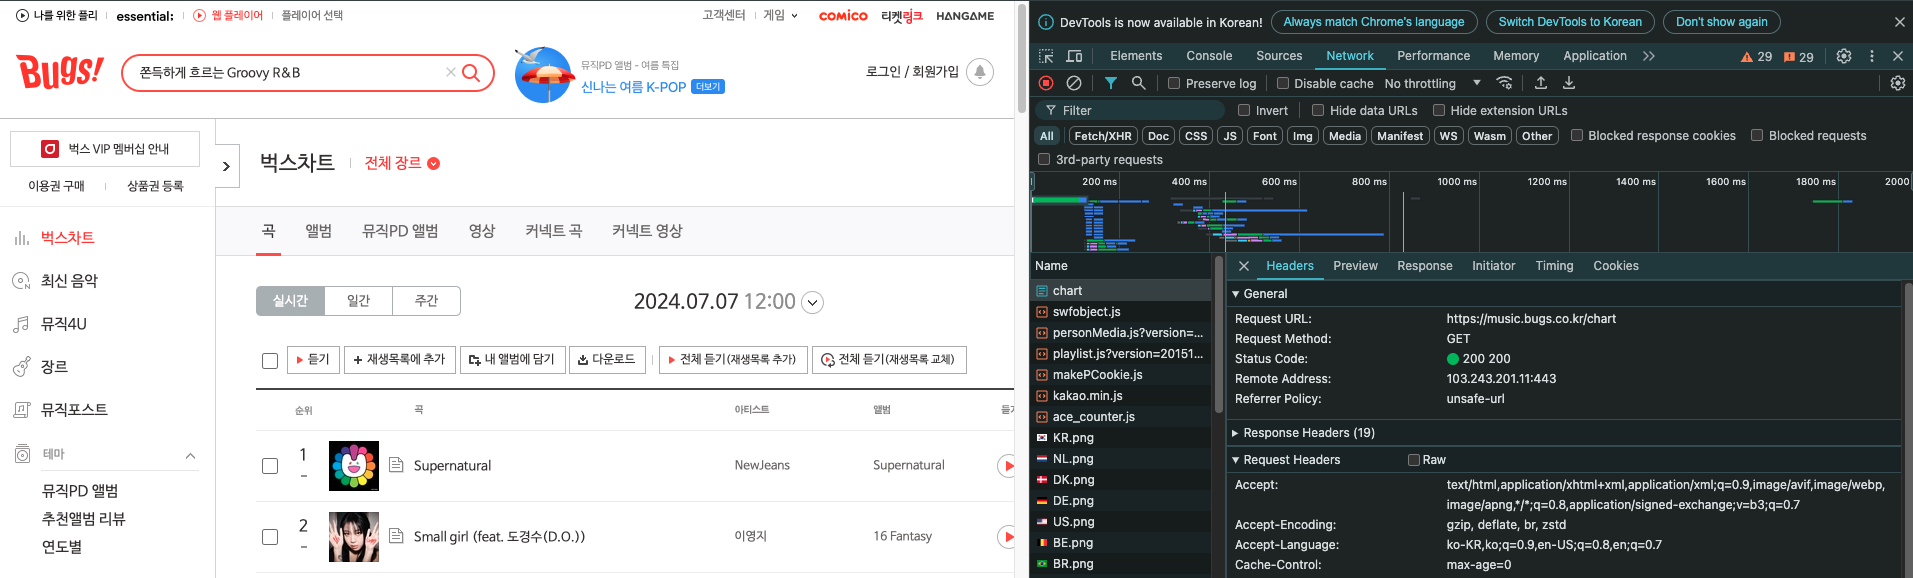

In [12]:
import requests
from bs4 import BeautifulSoup 

In [13]:
custom_header = {
  "referer": "https://music.bugs.co.kr/",
  "user-agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0.0.0 Safari/537.36"
}
url = "https://music.bugs.co.kr/chart"
req = requests.get(url, headers=custom_header)
soup = BeautifulSoup(req.text, "html.parser")

In [14]:
soup

<!DOCTYPE html>

<html lang="ko">
<head>
<!-- bgsw-wbugs-cb903 -->
<!-- Google tag (gtag.js) -->
<script async="" src="https://www.googletagmanager.com/gtag/js?id=G-ZQMQKQTGQJ"></script>
<script>
  window.dataLayer = window.dataLayer || [];
  function gtag(){dataLayer.push(arguments);}
  gtag('js', new Date());

  gtag('config', 'G-ZQMQKQTGQJ');
</script>
<script>
document.addEventListener('click', (e) => {
  const el = e.target.closest('[data-menu]');
  if (el) {
    gtag('event', 'home_gnb', { menu: el.dataset.menu });
    return;
  }

  const headerEl = e.target.closest('[data-header]');
  if (headerEl) {
    gtag('event', 'home', { header: headerEl.dataset.header });
    return;
  }

  for (const key of ['popular', 'recent', 'category', 'tag']) {
    const essentialEl = e.target.closest('[data-' + key + ']');
    if (essentialEl) {
      gtag('event', 'essential_home', { [key]: essentialEl.dataset[key] });
      return;
    }
  }
});
</script>
<meta charset="utf-8"/>
<meta content=

## 음원 추출

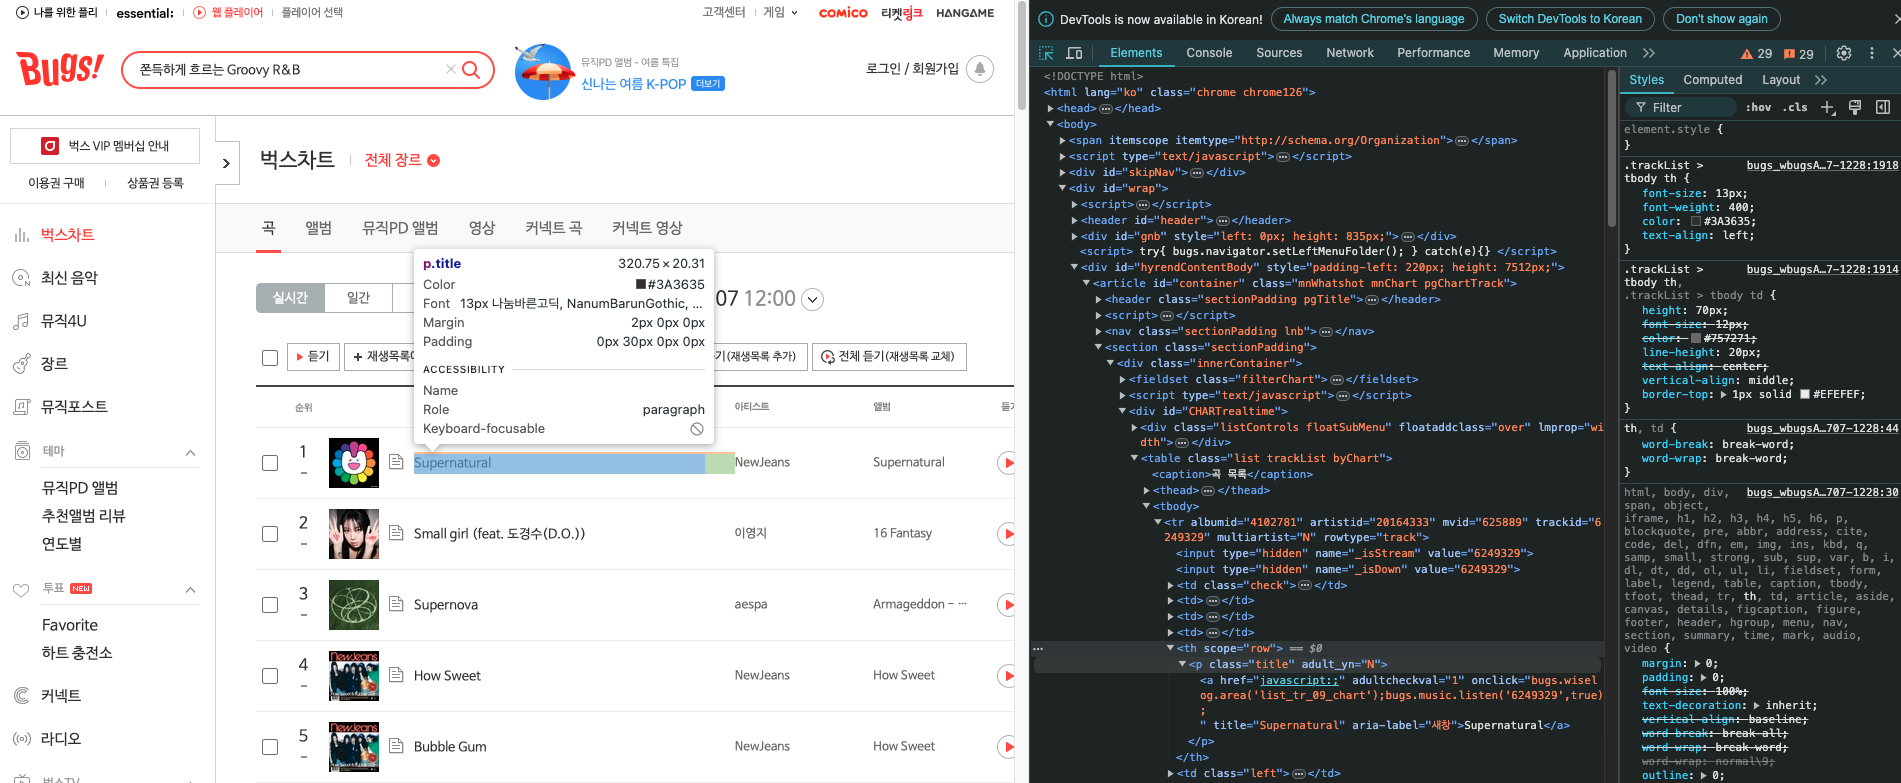

In [15]:
tbody = soup.find("tbody")
titles = tbody.find_all("p", class_="title")

len(titles)

100

In [16]:
titles[0].get_text()

'\nBloody Paradise\n'

In [17]:
titles[0].get_text().replace("\n","")

'Bloody Paradise'

## 함수

In [18]:
def crawling(soup):
  result = []

  tbody = soup.find("tbody")
  for p in tbody.find_all("p", class_="title"):
    result.append(p.get_text().replace("\n",""))

  return result

def main():
  custom_header = {
    "referer": "https://music.bugs.co.kr/",
    "user-agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0.0.0 Safari/537.36"
  }
  url = "https://music.bugs.co.kr/chart"
  req = requests.get(url, headers=custom_header)
  soup = BeautifulSoup(req.text, "html.parser")

  print(crawling(soup))

In [19]:
main()

['Bloody Paradise', 'BiiiG', 'LOVE ATTACK', 'BAD', '갑자기', 'REDRED', 'It′s Me', 'Pop Off Pop Off', 'LEMONADE', 'Deja Vu', '만찬가', "Surfin' Boy", 'Pretty Girl', 'Mmchk', 'Less than a Lover', 'HYPEMAN', 'Good Goodbye', '여름아 부탁해', '사랑하게 될 거야', 'Drowning', '캐치 캐치', 'Mmchk (English Version)', 'Lemon Tang', '0+0', 'Golden', '소문의 낙원', 'like JENNIE', '404 (New Era)', '생각을 멈추다 보면', 'Popcorn', 'Whiplash', 'RUDE!', 'Vitamin ME', '뛰어(JUMP)', 'Runaway', 'toxic till the end', 'Heavy Serenade', '너에게 닿기를', 'Pinball', '한 페이지가 될 수 있게', '청춘만화', '기쁨, 슬픔, 아름다운 마음', '입춘', '천상연', '멸종위기사랑', 'BANG BANG', 'APT.', 'WDA (Whole Different Animal) (Feat. G-DRAGON)', '봄 내음보다 너를', '모든 날, 모든 순간 (Every day, Every Moment)', '어떻게 이별까지 사랑하겠어, 널 사랑하는 거지', '타임캡슐', 'HAPPY', '나는 반딧불', '그대 작은 나의 세상이 되어', '첫 만남은 계획대로 되지 않아', 'Blue Valentine', '모르시나요(PROD.로코베리)', '그대만 있다면 (여름날 우리 X 너드커넥션 (Nerd Connection))', '사랑은 봄비처럼... 이별은 겨울비처럼', 'HOME SWEET HOME (feat. 태양, 대성)', 'Hype Boy', 'FOCUS', '고민중독', 'I AM', '에피소드', '소나기', 'OVERDRIVE', '

# [뉴스 기사 제목 예제](https://celltong.tistory.com/entry/%ED%8C%8C%EC%9D%B4%EC%8D%AC-%ED%81%AC%EB%A1%A4%EB%A7%81-%EA%B0%84%EB%8B%A8-%EC%8B%A4%EC%8A%B5-%EB%84%A4%EC%9D%B4%EB%B2%84-%EC%97%B0%ED%95%A9%EB%89%B4%EC%8A%A4-%EC%86%8D%EB%B3%B4-%EA%B8%B0%EC%82%AC%EC%A0%9C%EB%AA%A9-%EC%B6%94%EC%B6%9C) 

## html 문서 조회

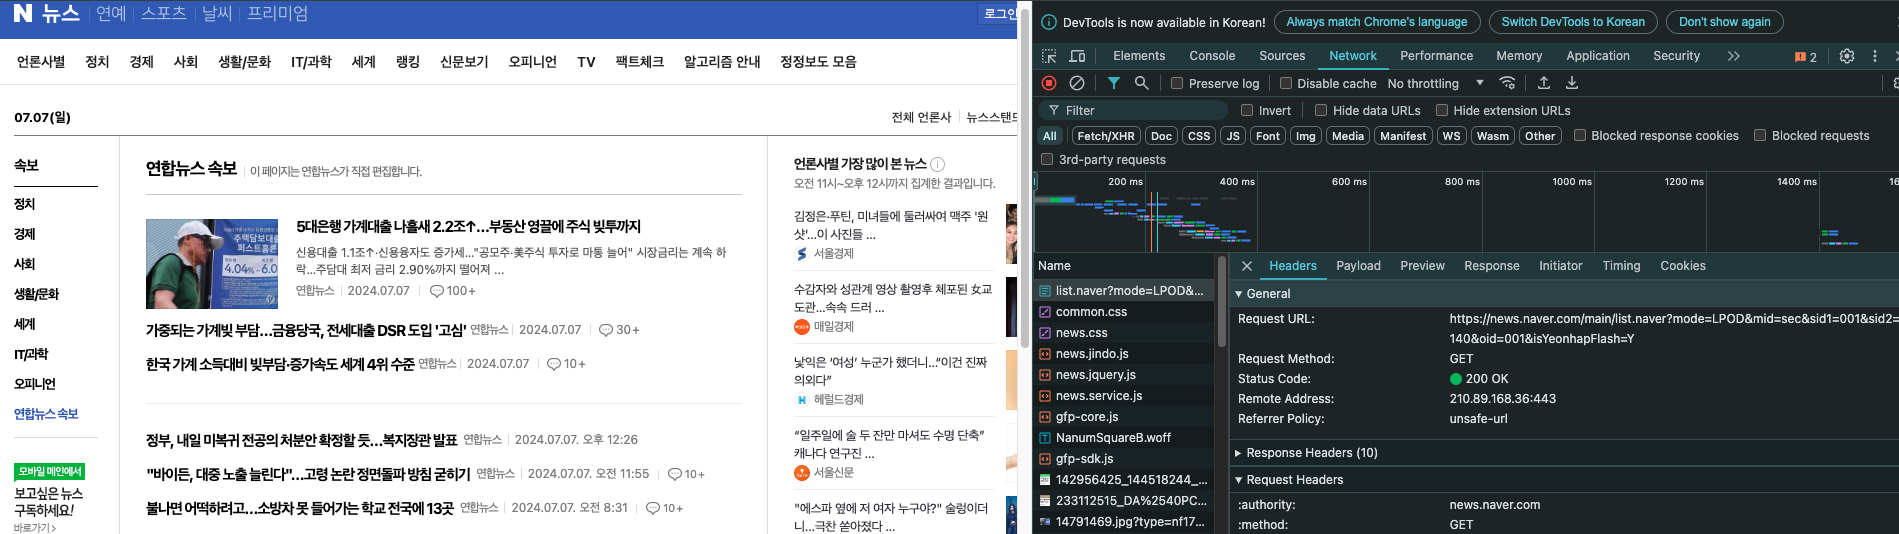

In [20]:
import requests
from bs4 import BeautifulSoup 

In [21]:
custom_header = {
  "referer": "https://news.naver.com/",
  "user-agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0.0.0 Safari/537.36"
}
url = "https://news.naver.com/main/list.naver?mode=LPOD&mid=sec&sid1=001&sid2=140&oid=001&isYeonhapFlash=Y"
req = requests.get(url, headers=custom_header)
soup = BeautifulSoup(req.text, "html.parser")

In [22]:
soup


<!DOCTYPE HTML>

<html lang="ko">
<head>
<meta charset="utf-8"/>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<meta contents="always" name="referrer"/>
<meta content="600" http-equiv="refresh"/>
<meta content="width=1106" name="viewport"/>
<meta content="네이버 뉴스" property="og:title"/>
<meta content="website" property="og:type"/>
<meta content="https://news.naver.com/main/list.naver?mode=LPOD&amp;mid=sec&amp;sid1=001&amp;sid2=140&amp;oid=001&amp;isYeonhapFlash=Y" property="og:url"/>
<meta content="https://ssl.pstatic.net/static.news/image/news/ogtag/navernews_800x420_20221201.png" property="og:image"/>
<meta content="다양한 기사 정보를 제공합니다." property="og:description"/>
<meta content="네이버" property="og:article:author"/>
<meta content="summary" name="twitter:card"/>
<meta content="네이버 뉴스" name="twitter:title"/>
<meta content="네이버 뉴스" name="twitter:site"/>
<meta content="네이버 뉴스" name="twitter:creator"/>
<meta content="https://ssl.pstatic.net/static.news/image/news/ogtag/navernews_800x4

## 기사 제목 추출

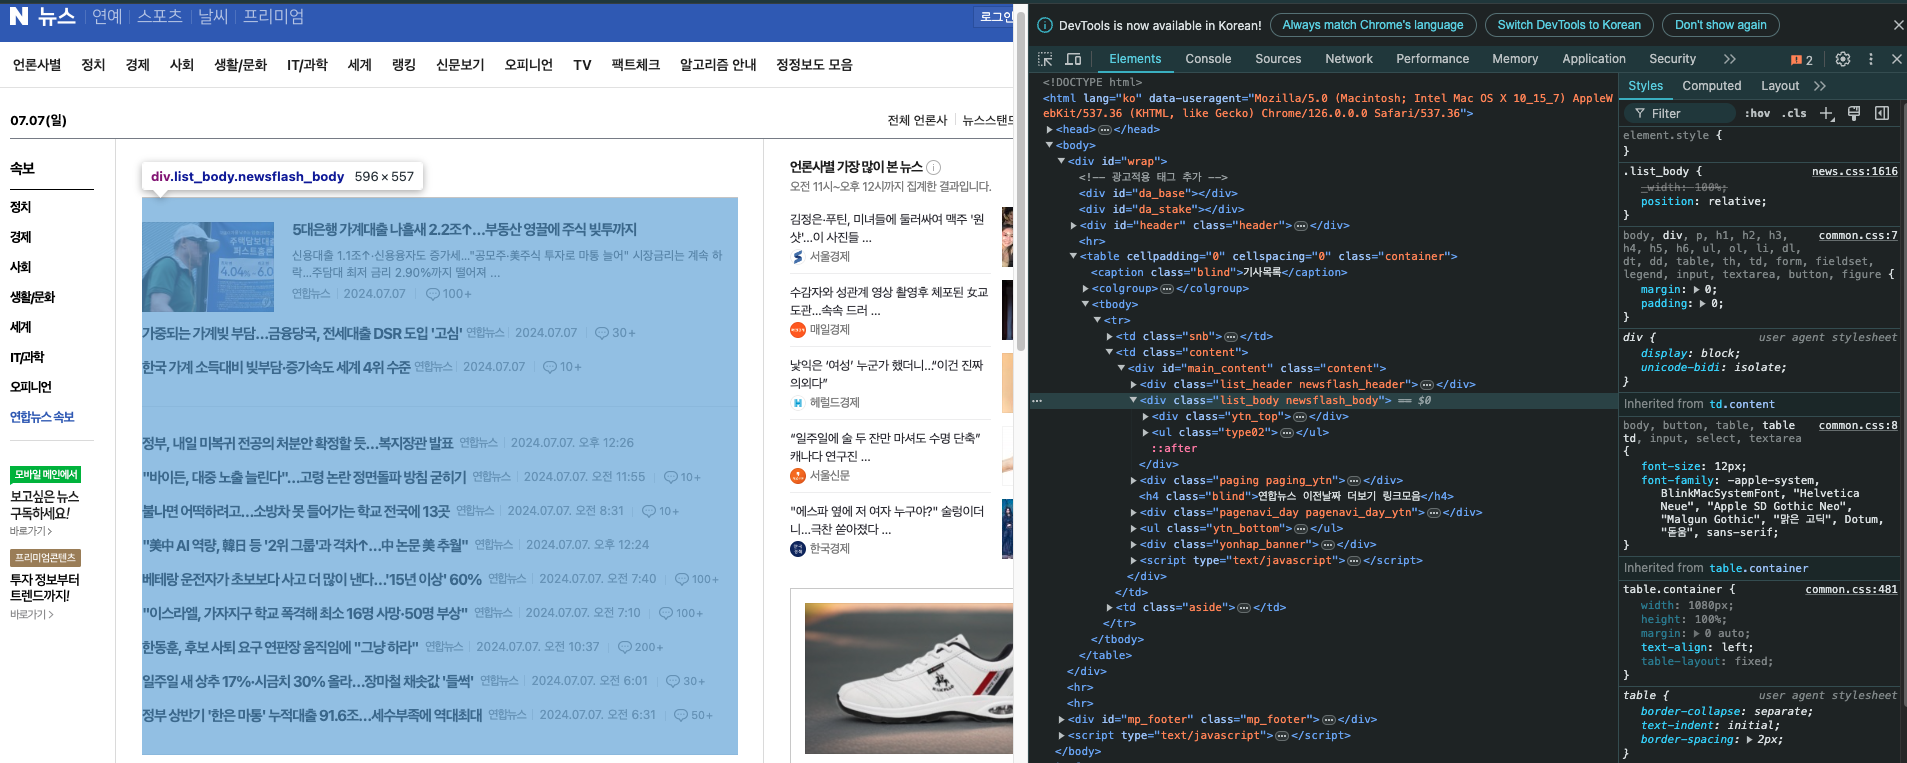

In [23]:
div = soup.find("div", "list_body")
a_list = div.find_all("a")

titles = [ a.get_text().replace("\n","") for a in a_list if len(a.get_text().replace("\n","")) > 0 ]
len(titles)

12

In [24]:
titles[0]

'김민석 "부득이한 비거주 1주택 사유 폭넓게 인정…사각 없애야"'

## 함수

In [25]:
def crawling(soup):
  result = []

  div = soup.find("div", "list_body")
  for a in div.find_all("a"):
    _tmp = a.get_text().replace("\n","")
    if len(_tmp) > 0:
      result.append(_tmp)

  return result

def main():
  custom_header = {
    "referer": "https://news.naver.com/",
    "user-agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0.0.0 Safari/537.36"
  }
  url = "https://news.naver.com/main/list.naver?mode=LPOD&mid=sec&sid1=001&sid2=140&oid=001&isYeonhapFlash=Y"
  req = requests.get(url, headers=custom_header)
  soup = BeautifulSoup(req.text, "html.parser")

  print(crawling(soup))

In [26]:
main()

['김민석 "부득이한 비거주 1주택 사유 폭넓게 인정…사각 없애야"', '강훈식 "與, 주택용지 확보방안 제시해주면 靑·정부 적극 검토"', '韓총리 "민생·개혁 실질성과 내야…해결책 만드는 당정청"', '임광현 "고가 법인주택 42%는 \'황제사택\'…최고가 200억 넘어"', "수면위로 드러난 대법관 '밀실합의'…인선절차 개선 필요성 부각", '술 줄이는 한국인…맥주·소주·막걸리 출고 일제히 감소', '작년 국민연금 받는다고 깎인 기초연금 804억원…4년새 3배', '명진스님 입적에 불교계 안팎 애도…장례는 종교시민사회장으로', '극한호우 7일째 거제·통영 691명 미귀가…대피생활 장기화 조짐', '경찰 무사하다 했는데 51일간 실종상태…재신고후 시신 발견', '난임치료휴가 유급기간 2일→4일 확대…불리한 처우시 처벌', '범죄 고발 유튜버, 수십억대 중고차 대출사기로 징역 7년']


# 주식 WICS 코드 예제

## [주식 종목 코드 조회](https://www.ktb.co.kr/trading/popup/itemPop.jspx)

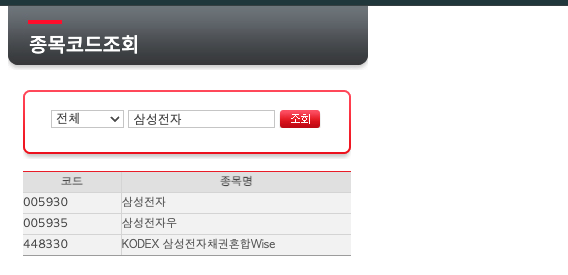

## html 문서 조회 

In [27]:
import requests
from bs4 import BeautifulSoup 

In [28]:
stock_code = "005930" # 삼성전자
url = "https://finance.naver.com/item/coinfo.naver?code={stock_code}".format(stock_code=stock_code)

custom_header = {
  "referer": "https://finance.naver.com/item/main.naver/",
  "user-agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0.0.0 Safari/537.36"
}
req = requests.get(url, headers=custom_header)
soup = BeautifulSoup(req.text, "html.parser")

In [29]:
soup

<!--  global include -->
<html lang="ko">
<head>
<title>삼성전자 : Npay 증권</title>
<meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
<meta content="text/javascript" http-equiv="Content-Script-Type"/>
<meta content="text/css" http-equiv="Content-Style-Type"/>
<meta content="Npay 증권" name="apple-mobile-web-app-title"/>
<meta content="Npay 증권" property="og:title"/>
<meta content="https://ssl.pstatic.net/static/m/stock/im/2016/08/og_stock-200.png" property="og:image"/>
<meta content="https://finance.naver.com" property="og:url"/>
<meta content="국내 해외 증시 지수, 시장지표, 뉴스, 증권사 리서치 등 제공" property="og:description"/>
<meta content="article" property="og:type"/>
<meta content="" property="og:article:thumbnailUrl"/>
<meta content="Npay 증권" property="og:article:author"/>
<meta content="http://FINANCE.NAVER.COM" property="og:article:author:url"/>
<link href="https://ssl.pstatic.net/imgstock/static.pc/20260731153938/css/finance_header.css" rel="stylesheet" type="text/css"/>
<link href="ht

## WICS 코드 추출 > 없음

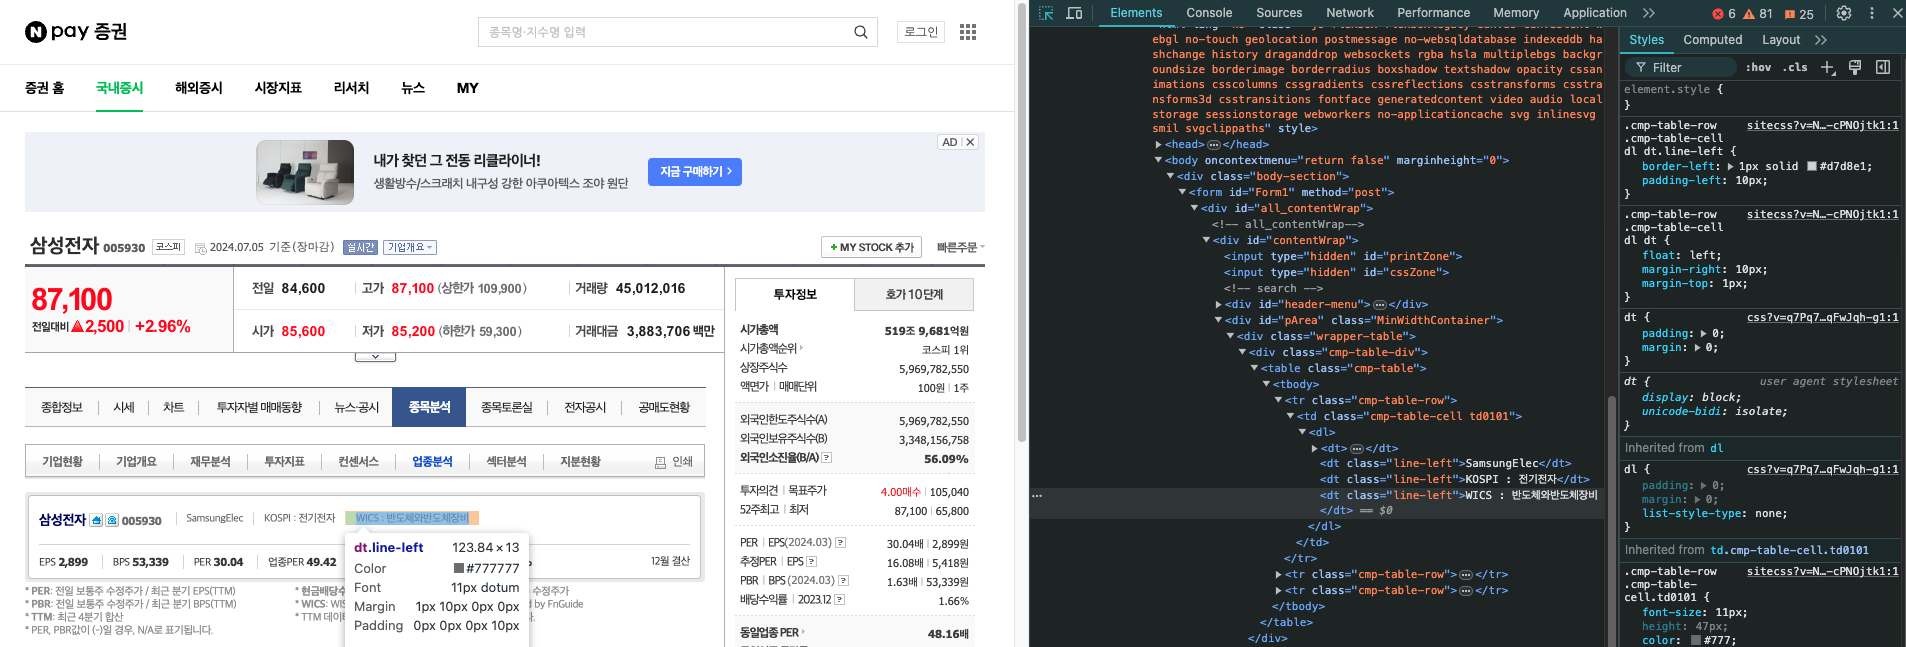

In [30]:
soup.find_all("dt", class_="line-left")

[]

## Network > url 확인
- 일반적으로 웹페이지는 여러개의 documents(html)을 통해 화면을 랜더링합니다.
- 따라서 필요한 데이터가 어떤 문서(html)에 있는지 확인할 필요가 있습니다.

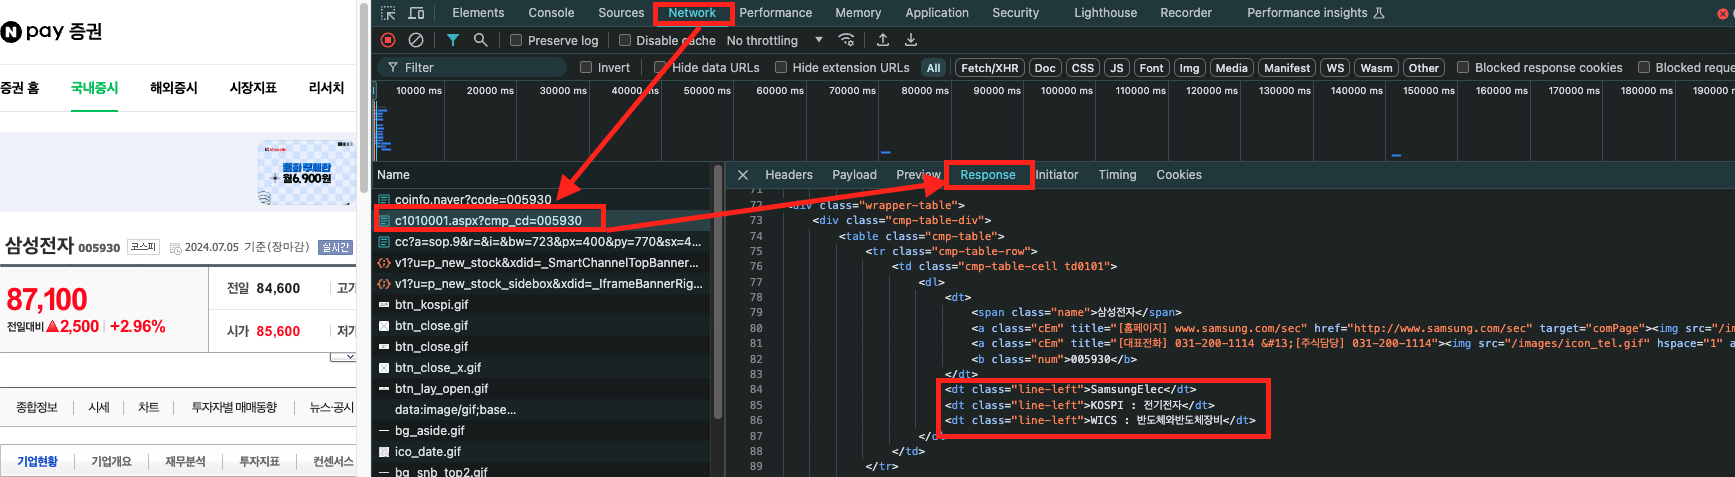

- url을 찾았다면,
  - 아래와 같이 headers를 통해 필요한 내용을 추출

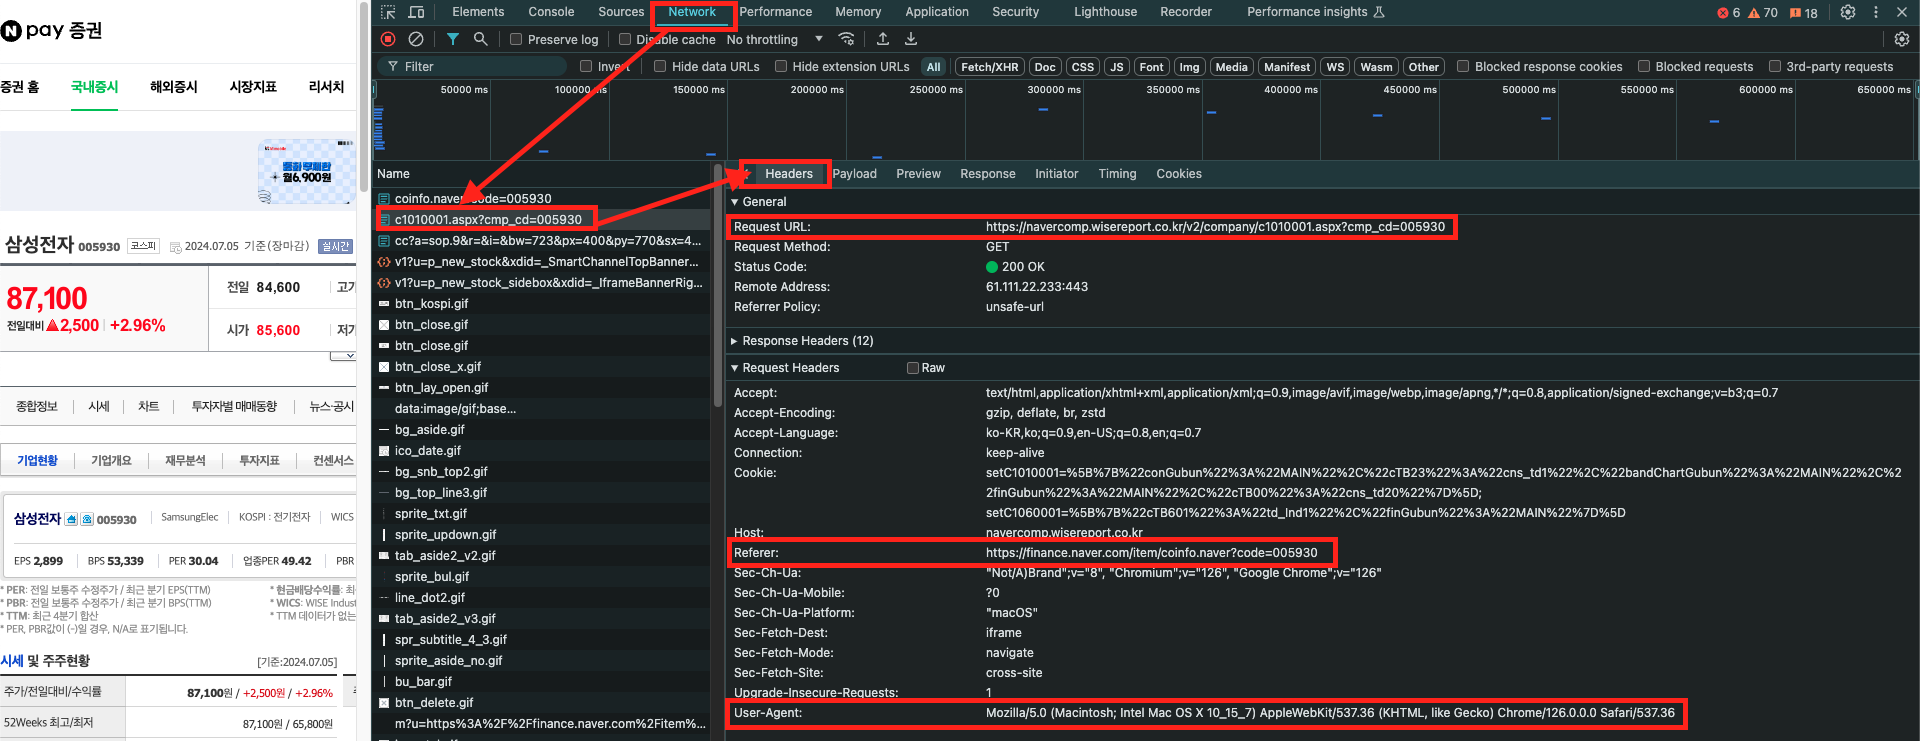

In [31]:
stock_code = "005930" # 삼성전자

url = 'https://navercomp.wisereport.co.kr/v2/company/c1010001.aspx?cmp_cd={stock_code}'.format(stock_code=stock_code)
headers = {
  'User-Agent':'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36',
  'Referer':'https://finance.naver.com/item/coinfo.naver?code={stock_code}'.format(stock_code=stock_code)
}
response = requests.get(url, headers=headers)

soup = bs(response.text, "html.parser")

In [32]:
soup.find_all("dt", class_="line-left")

[<dt class="line-left"><a href="../company/c1020001.aspx?cmp_cd=005930&amp;cn=">기업개요</a></dt>,
 <dt class="line-left"><a href="../company/c1030001.aspx?cmp_cd=005930&amp;cn=">재무분석</a></dt>,
 <dt class="line-left"><a href="../company/c1040001.aspx?cmp_cd=005930&amp;cn=">투자지표</a></dt>,
 <dt class="line-left"><a href="../company/c1050001.aspx?cmp_cd=005930&amp;cn=">컨센서스</a></dt>,
 <dt class="line-left"><a href="../company/c1060001.aspx?cmp_cd=005930&amp;cn=">업종분석</a></dt>,
 <dt class="line-left"><a href="../company/c1090001.aspx?cmp_cd=005930&amp;cn=">섹터분석</a></dt>,
 <dt class="line-left"><a href="../company/c1070001.aspx?cmp_cd=005930&amp;cn=">지분현황</a></dt>,
 <dt class="line-left">SamsungElec</dt>,
 <dt class="line-left">KOSPI : 코스피 전기·전자</dt>,
 <dt class="line-left">WICS : 반도체와반도체장비</dt>,
 <dt class="line-left">BPS <b class="num">86,052</b></dt>,
 <dt class="line-left">PER <b class="num">12.63</b></dt>,
 <dt class="line-left">업종PER <b class="num">18.07</b></dt>,
 <dt class="line-left">P

In [33]:
soup.find_all("dt", class_="line-left")[9].get_text()

'WICS : 반도체와반도체장비'

In [34]:
for node in soup.find_all("dt", class_="line-left"):
  if 'WICS' in node.get_text():
    print(node.get_text().replace('WICS : ', ''))

반도체와반도체장비


## 함수

In [35]:
def crawling(soup):
  for node in soup.find_all("dt", class_="line-left"):
    if 'WICS' in node.get_text():
      return node.get_text().replace('WICS : ', '')

def main(stock_code):
  custom_header = {
    'User-Agent':'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36',
    'Referer':'https://finance.naver.com/item/coinfo.naver?code={stock_code}'.format(stock_code=stock_code)
  }
  url = 'https://navercomp.wisereport.co.kr/v2/company/c1010001.aspx?cmp_cd={stock_code}'.format(stock_code=stock_code)
  req = requests.get(url, headers=custom_header)
  soup = BeautifulSoup(req.text, "html.parser")

  print(crawling(soup))

In [36]:
main(stock_code = "005930") # 삼성전자

반도체와반도체장비


In [37]:
main(stock_code = "035720") # 카카오

양방향미디어와서비스
